In [7]:
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
 
# X_train
n_train = 50
X_train = np.random.normal(0, 1, n_train)
 
# Y = sinc(X) + noise
sigma_noise = 0.25
Y_train = np.sinc(X_train) + np.random.normal(0, sigma_noise, n_train)
 
# X_test
n_test = 450
X_test = np.random.normal(0.5, 0.3, n_test)
 
Y_test = np.sinc(X_test) + np.random.normal(0, sigma_noise, n_test)
 
# w_i
def compute_weights(X_train, mu_train=0, sigma_train=1, mu_test=0.5, sigma_test=0.3):
    p_train = norm.pdf(X_train, mu_train, sigma_train)
    p_test  = norm.pdf(X_train, mu_test, sigma_test)
    return p_test / p_train
 
weights = compute_weights(X_train)

In [8]:
# use a linear model
def predict(X, theta):
    return theta[0] + theta[1] * X
 
# for single observation
def log_likelihood(y, x, theta, sigma=sigma_noise):
    y_pred = predict(x, theta)
    return norm.logpdf(y, y_pred, sigma)
 
# prior: Normal on both parameters
def log_prior(theta, mu=0, sigma=1):
    return np.sum(norm.logpdf(theta, mu, sigma))
 
 
# base score function for quasi-posterior: s_i(Y_i, theta) = w_i * log p(Y_i | theta)
def score_function(y, x, theta, weight):
    return weight * log_likelihood(y, x, theta)
 
# quasi-posterior with inverse temperature alpha: pi_alpha propto exp{alpha * sum_i s_i} * pi
def log_quasi_posterior(theta, Y, X, weights, alpha):
    log_qp = log_prior(theta)
    for i in range(len(Y)):
        log_qp += alpha * score_function(Y[i], X[i], theta, weights[i])
    return log_qp
 
# Sample from quasi-posterior (Metropolis-Hastings)
def sample_quasi_posterior(Y, X, weights, alpha, num_samples=7000, burn_in=100):
    theta = np.array([0.0, 0.0])  # initial value
    samples = []
    for i in range(num_samples + burn_in):
        # Propose new theta
        theta_new = theta + np.random.normal(loc=0, scale=0.35, size=2)
 
        # Acceptance ratio (renamed from log_alpha to avoid confusion with the alpha parameter)
        log_accept = (
            log_quasi_posterior(theta_new, Y, X, weights, alpha) -
            log_quasi_posterior(theta,     Y, X, weights, alpha)
        )
 
        # Accept/reject
        if np.log(np.random.rand()) < log_accept:
            theta = theta_new
 
        if i >= burn_in:
            samples.append(theta)
 
    return np.array(samples)
 
# Sample from quasi-posterior (alpha=1: standard importance-weighted posterior)
posterior_samples = sample_quasi_posterior(Y_train, X_train, weights, alpha=1.0)
print(f"Sampled {len(posterior_samples)} posterior samples")
print(f"Posterior mean: {posterior_samples.mean(axis=0)}")
print(f"OLS: {np.polyfit(X_train, Y_train, deg=1)[::-1]}")
 
 
def compute_pcic(Y, X, weights, posterior_samples, alpha, beta):
    """
    PCIC(alpha, beta) with tempered score (alpha) and tempered evaluation (beta):
      term1 = -1/n * sum_i w_i * log E_pos[ h_i(Y_i|theta)^beta ]
      term2 =  1/n * alpha * beta * sum_i w_i * Cov_pos[ log h_i(Y_i|theta), s_i(Y_i, theta) ]
    Posterior is sampled under the alpha-quasi-posterior.
    """
    n = len(Y)
    term1 = term2 = 0
 
    for i in range(n):
        log_liks = np.array([log_likelihood(Y[i], X[i], theta) for theta in posterior_samples])
 
        # Term 1: beta-tempered predictive density  log E_pos[h_i^beta]
        log_expectation = logsumexp(beta * log_liks) - np.log(len(posterior_samples))
        term1 -= weights[i] * log_expectation
 
        # Term 2: Cov_pos[log h_i, s_i], scaled by alpha * beta
        scores = np.array([score_function(Y[i], X[i], theta, weights[i]) for theta in posterior_samples])
        cov = np.mean((log_liks - np.mean(log_liks)) * (scores - np.mean(scores)))
        term2 += weights[i] * alpha * beta * cov
 
    pcic = (term1 + term2) / n
    return pcic, term1, term2

Sampled 7000 posterior samples
Posterior mean: [ 1.14071526 -0.94365352]
OLS: [0.45849535 0.1541971 ]


In [9]:
# pcic, term1, term2 = compute_pcic(Y_train, X_train, weights, posterior_samples, alpha=1.0, beta=1.0)
# print(f"\nPCIC = {pcic:.4f}")
# print(f"  training loss: {term1:.4f}")
# print(f"  correction: {term2:.4f}")
 
def compute_generalization_error(X_test, Y_test, posterior_samples):
    n_test = len(X_test)
    gen_error = 0
 
    for i in range(n_test):
        log_liks = np.array([
            log_likelihood(Y_test[i], X_test[i], theta) for theta in posterior_samples
        ])
        log_pred_density = logsumexp(log_liks) - np.log(len(posterior_samples))
        gen_error -= log_pred_density
 
    return gen_error / n_test
 
gen_error = compute_generalization_error(X_test, Y_test, posterior_samples)
print(f"True generalization error: {gen_error:.4f}")

True generalization error: 0.1241


In [10]:
alpha_values = np.linspace(0.0, 2.8, 14)
beta_values  = np.linspace(0.0, 2.8, 14)
 
posterior_dict = {}
 
for alpha in alpha_values:
    print(f"sampling posterior for alpha = {alpha:.2f}")
 
    posterior_dict[alpha] = sample_quasi_posterior(
        Y_train,
        X_train,
        weights,
        alpha=alpha,
        num_samples=2000,
        burn_in=200
    )

sampling posterior for alpha = 0.00
sampling posterior for alpha = 0.22
sampling posterior for alpha = 0.43
sampling posterior for alpha = 0.65
sampling posterior for alpha = 0.86
sampling posterior for alpha = 1.08
sampling posterior for alpha = 1.29
sampling posterior for alpha = 1.51
sampling posterior for alpha = 1.72
sampling posterior for alpha = 1.94
sampling posterior for alpha = 2.15
sampling posterior for alpha = 2.37
sampling posterior for alpha = 2.58
sampling posterior for alpha = 2.80


In [11]:
import matplotlib.pyplot as plt
 
def compute_waic(Y, X, posterior_samples):
    total = 0
 
    for i in range(len(Y)):
        log_liks = np.array([log_likelihood(Y[i], X[i], theta) for theta in posterior_samples])
        log_expectation = logsumexp(log_liks) - np.log(len(posterior_samples))
        variance = np.var(log_liks)
        total += variance - log_expectation
 
    return total / len(Y)
 
# Grids: rows = beta index, columns = alpha index.
# WAIC and gen_error don't depend on beta — they are constant along each row.
pcic_grid      = np.zeros((len(beta_values), len(alpha_values)))
waic_grid      = np.zeros((len(beta_values), len(alpha_values)))
gen_error_grid = np.zeros((len(beta_values), len(alpha_values)))
 
for j, alpha in enumerate(alpha_values):
    posterior_samples = posterior_dict[alpha]
 
    # WAIC and gen_error only depend on alpha (not beta)
    waic      = compute_waic(Y_train, X_train, posterior_samples)
    gen_error = compute_generalization_error(X_test, Y_test, posterior_samples)
 
    for i, beta in enumerate(beta_values):
        pcic, _, _ = compute_pcic(
            Y_train, X_train, weights, posterior_samples, alpha, beta
        )
        pcic_grid[i, j]      = pcic
        waic_grid[i, j]      = waic       # constant in beta
        gen_error_grid[i, j] = gen_error  # constant in beta

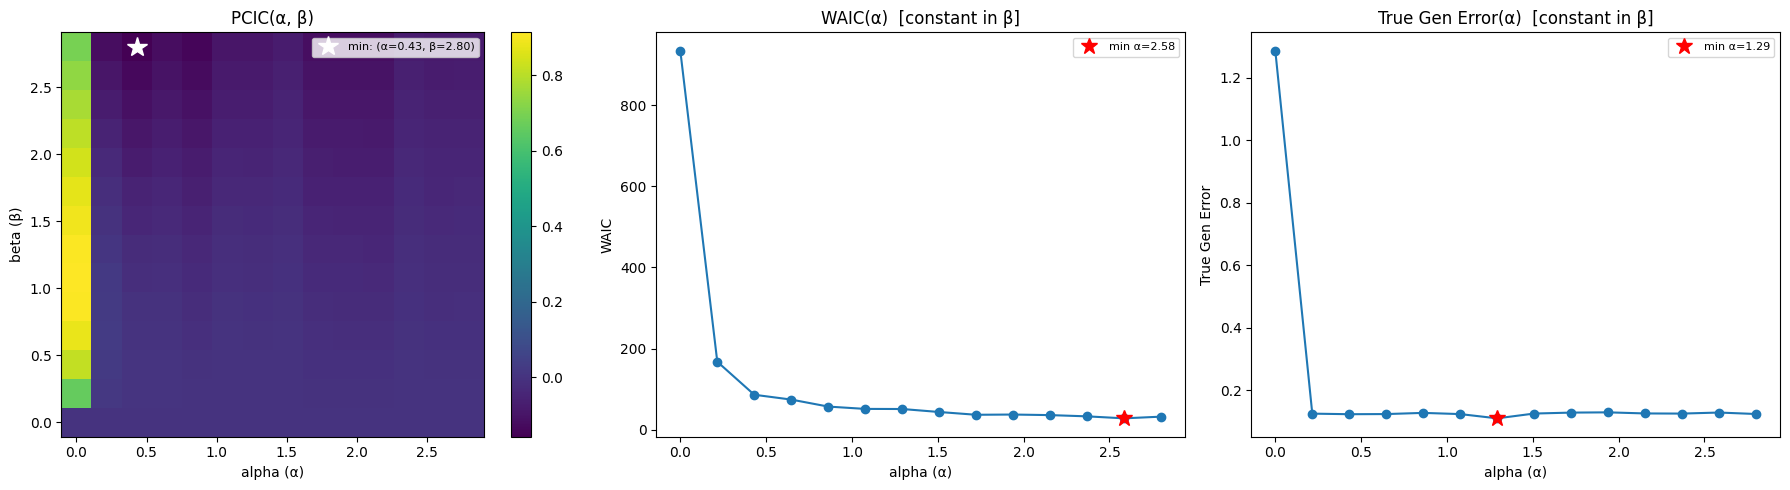

best (alpha, beta) according to PCIC:      (0.43, 2.80)
best alpha according to WAIC:              2.58
best alpha according to true gen error:    1.29


In [12]:
# Plot: PCIC heatmap + simple line plots for WAIC and True Gen Error (constant in beta)
A, B = np.meshgrid(alpha_values, beta_values)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_heatmap(ax, grid, title):
    im = ax.pcolormesh(A, B, grid, cmap='viridis', shading='nearest')
    plt.colorbar(im, ax=ax)
 
    # Mark global minimum
    min_idx = np.unravel_index(np.argmin(grid), grid.shape)
    ax.plot(
        alpha_values[min_idx[1]], beta_values[min_idx[0]],
        'w*', markersize=15,
        label=f'min: (α={alpha_values[min_idx[1]]:.2f}, β={beta_values[min_idx[0]]:.2f})'
    )
    ax.set_xlabel('alpha (α)')
    ax.set_ylabel('beta (β)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    return min_idx

min_pcic = plot_heatmap(axes[0], pcic_grid, 'PCIC(α, β)')

# WAIC: simple line plot vs alpha (constant in beta)
waic_per_alpha = waic_grid[0, :]
axes[1].plot(alpha_values, waic_per_alpha, marker='o')
min_waic_idx = np.argmin(waic_per_alpha)
axes[1].plot(alpha_values[min_waic_idx], waic_per_alpha[min_waic_idx], 'r*', markersize=12,
             label=f'min α={alpha_values[min_waic_idx]:.2f}')
axes[1].set_xlabel('alpha (α)')
axes[1].set_ylabel('WAIC')
axes[1].set_title('WAIC(α)  [constant in β]')
axes[1].legend(loc='best', fontsize=8)

# True generalization error: simple line plot vs alpha (constant in beta)
gen_per_alpha = gen_error_grid[0, :]
axes[2].plot(alpha_values, gen_per_alpha, marker='o')
min_true_idx = np.argmin(gen_per_alpha)
axes[2].plot(alpha_values[min_true_idx], gen_per_alpha[min_true_idx], 'r*', markersize=12,
             label=f'min α={alpha_values[min_true_idx]:.2f}')
axes[2].set_xlabel('alpha (α)')
axes[2].set_ylabel('True Gen Error')
axes[2].set_title('True Gen Error(α)  [constant in β]')
axes[2].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

print(f"best (alpha, beta) according to PCIC:      ({alpha_values[min_pcic[1]]:.2f}, {beta_values[min_pcic[0]]:.2f})")
print(f"best alpha according to WAIC:              {alpha_values[min_waic_idx]:.2f}")
print(f"best alpha according to true gen error:    {alpha_values[min_true_idx]:.2f}")